In [3]:
import pandas as pd
import matplotlib.pyplot as plt


## Load dataset...


In [4]:
df = pd.read_csv("term-deposit-marketing-2020.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Basic dataset information

In [5]:
print("\nDataset Size:")
print(df.shape)

print("\nFirst 5 Records:")
print(df.head())

print("\nLast 5 Records:")
print(df.tail())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()


Dataset Size:
(40000, 14)

First 5 Records:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign   y  
0  unknown    5   may       261         1  no  
1  unknown    5   may       151         1  no  
2  unknown    5   may        76         1  no  
3  unknown    5   may        92         1  no  
4  unknown    5   may       198         1  no  

Last 5 Records:
       age         job   marital  education default  balance housing loan  \
39995   53  technician   married   tertiary      no      395      no   no   
39996   30  management    single   tertiary      no

## Check missing and duplicate values

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

Total Missing Values:
0

Duplicate Rows:
0


## Statistical summary

In [7]:
print("\nNumerical Columns Summary:")
print(df.describe())

print("\nCategorical Columns Summary:")
print(df.describe(include="object"))


Numerical Columns Summary:
                age        balance           day      duration      campaign
count  40000.000000   40000.000000  40000.000000  40000.000000  40000.000000
mean      40.544600    1274.277550     16.017225    254.824300      2.882175
std        9.641776    2903.769716      8.278127    259.366498      3.239051
min       19.000000   -8019.000000      1.000000      0.000000      1.000000
25%       33.000000      54.000000      8.000000    100.000000      1.000000
50%       39.000000     407.000000     17.000000    175.000000      2.000000
75%       48.000000    1319.000000     21.000000    313.000000      3.000000
max       95.000000  102127.000000     31.000000   4918.000000     63.000000

Categorical Columns Summary:
                job  marital  education default housing   loan   contact  \
count         40000    40000      40000   40000   40000  40000     40000   
unique           12        3          4       2       2      2         3   
top     blue-collar  

## Target variable analysis


Subscription Counts:
y
no     37104
yes     2896
Name: count, dtype: int64

Subscription Percentage:
y
no     92.76
yes     7.24
Name: proportion, dtype: float64


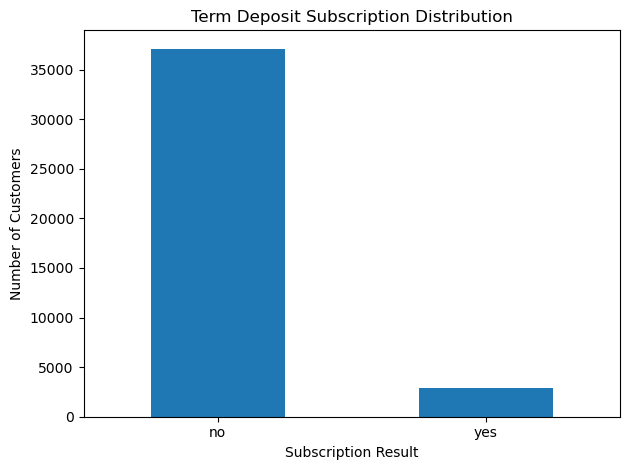

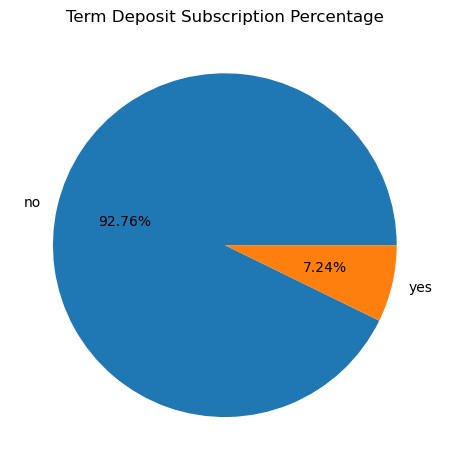

In [8]:
print("\nSubscription Counts:")
print(df["y"].value_counts())

print("\nSubscription Percentage:")
print(
    df["y"].value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# Bar chart
df["y"].value_counts().plot(
    kind="bar"
)

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription Result")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Pie chart
df["y"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%"
)

plt.title("Term Deposit Subscription Percentage")
plt.ylabel("")
plt.tight_layout()
plt.show()



## Separate numerical and categorical columns

In [24]:

# Convert Day into Week Groups


df["day_group"] = pd.cut(
    df["day"],
    bins=[0, 7, 14, 21, 31],
    labels=[
        "Week 1 (1-7)",
        "Week 2 (8-14)",
        "Week 3 (15-21)",
        "Week 4 (22-31)"
    ]
)


numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Remove original day column
numerical_columns.remove("day")

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_columns.remove("y")

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)


Numerical Columns:
['age', 'balance', 'duration', 'campaign']

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'quarter', 'day_group']


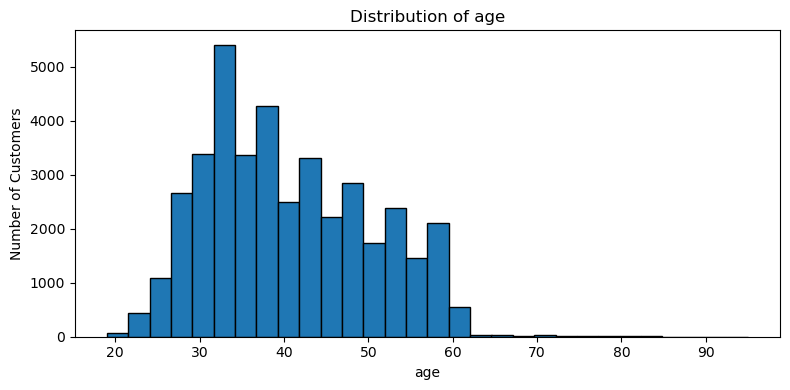

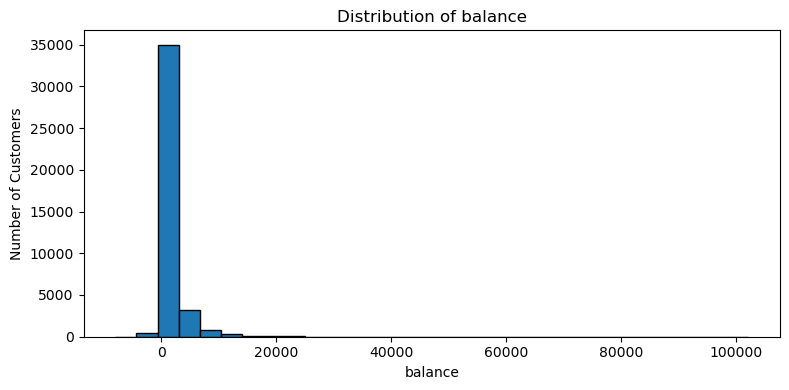

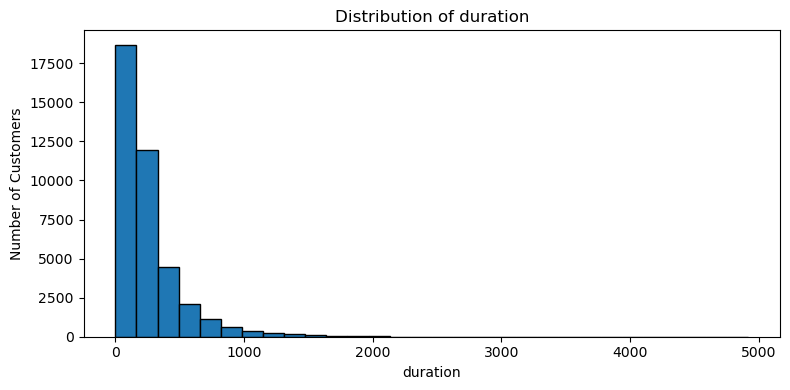

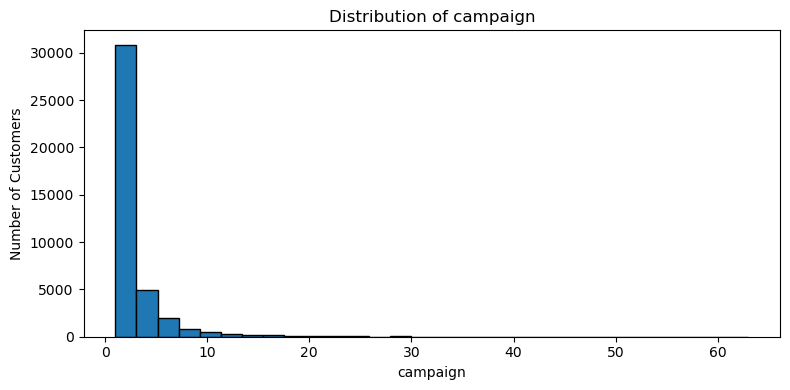

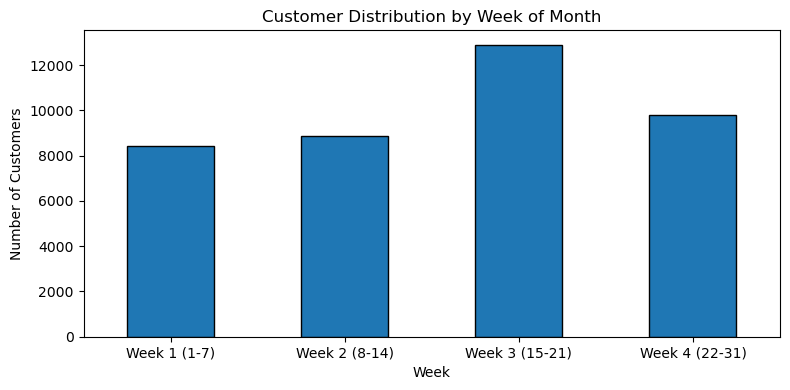

In [25]:
# Numerical Column Distributions

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df[column],
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

# Day Distribution (Week-wise)

week_order = [
    "Week 1 (1-7)",
    "Week 2 (8-14)",
    "Week 3 (15-21)",
    "Week 4 (22-31)"
]

df["day_group"] = pd.Categorical(
    df["day_group"],
    categories=week_order,
    ordered=True
)

week_distribution = (
    df["day_group"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,4))

week_distribution.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Customer Distribution by Week of Month")
plt.xlabel("Week")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_columns.remove("y")

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)


Numerical Columns:
['age', 'balance', 'day', 'duration', 'campaign']

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'quarter']


## Numerical columns distribution

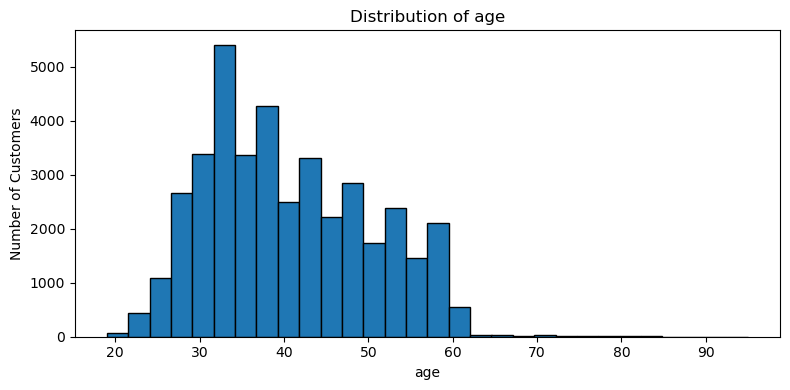

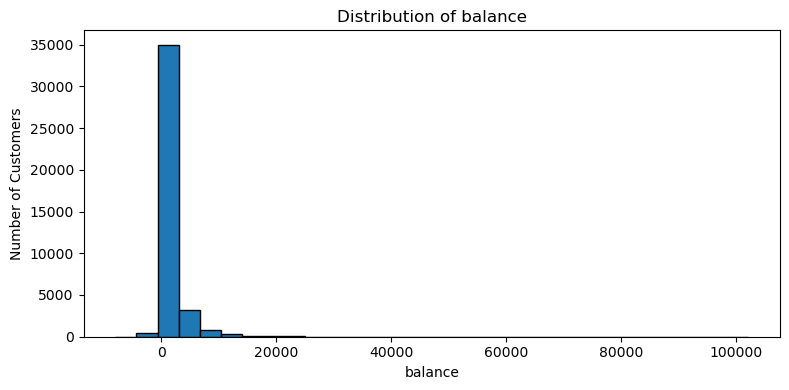

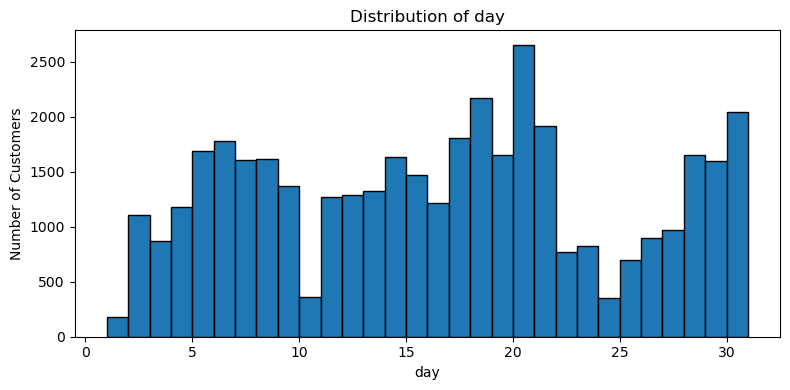

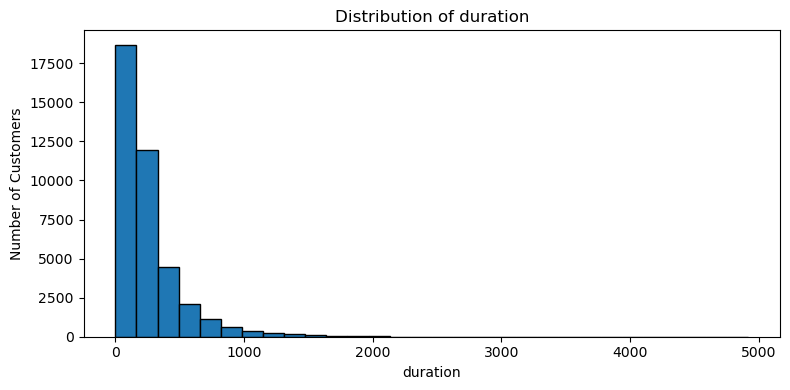

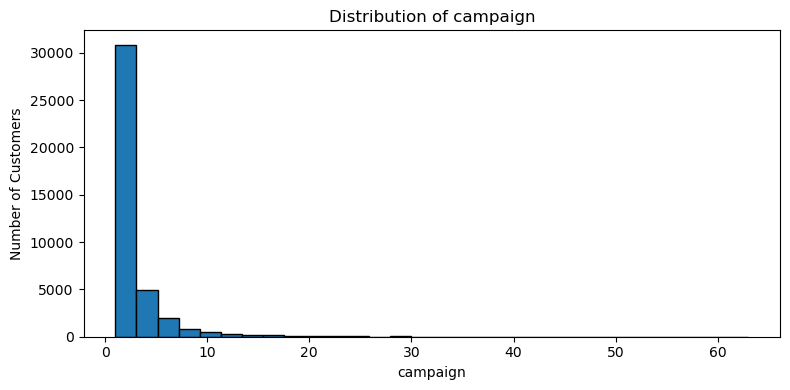

In [27]:
for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df[column],
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

## Box plots for numerical columns

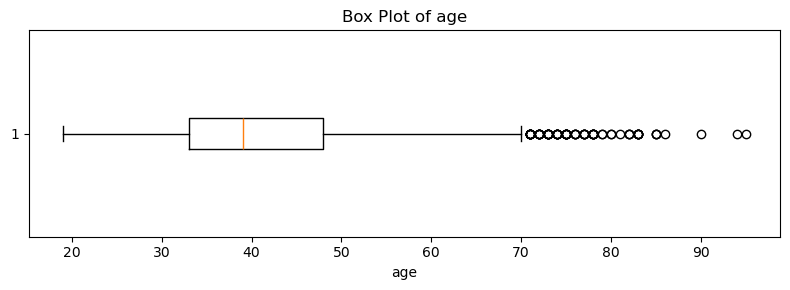

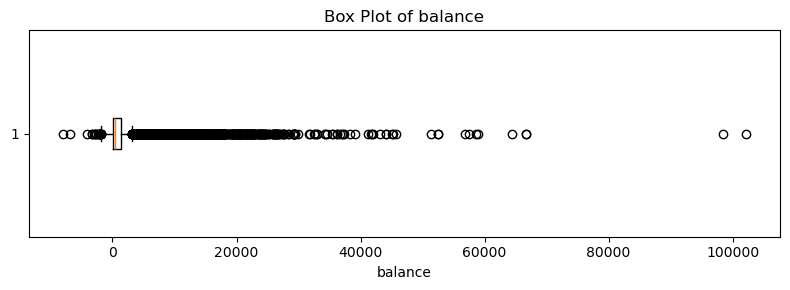

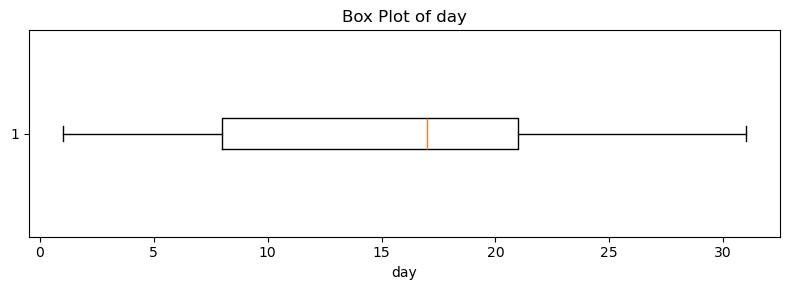

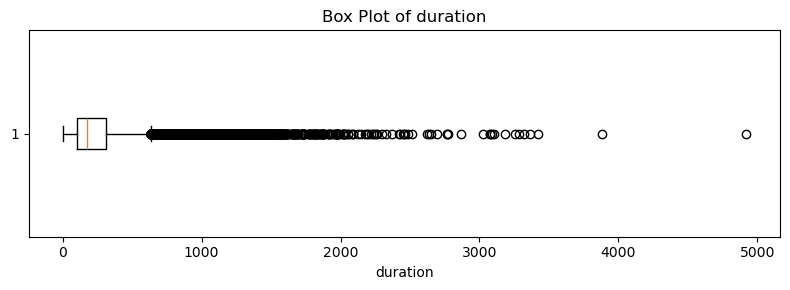

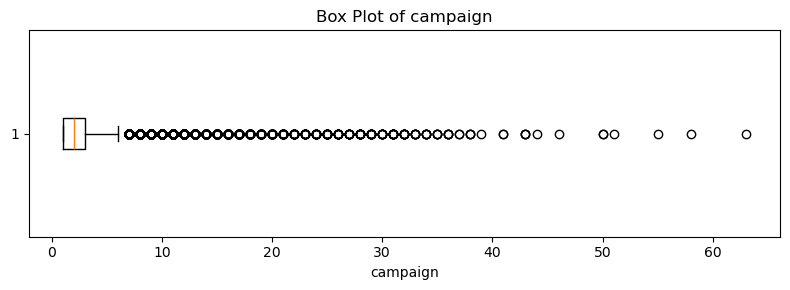

In [28]:
for column in numerical_columns:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[column],
        vert=False
    )

    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

## Categorical columns distribution

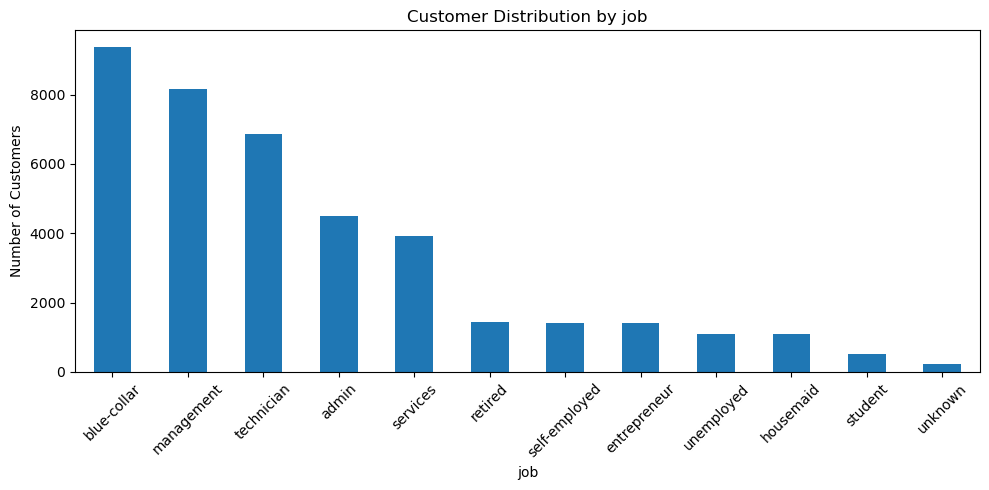

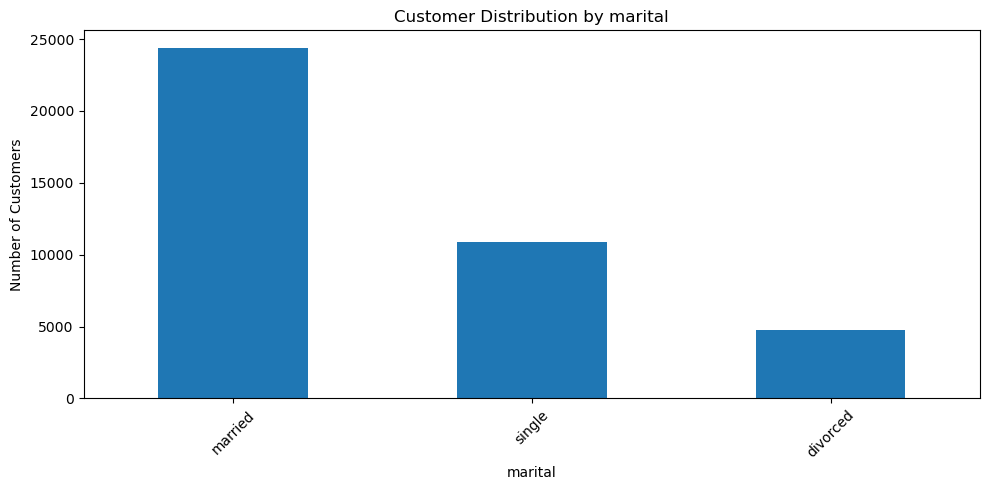

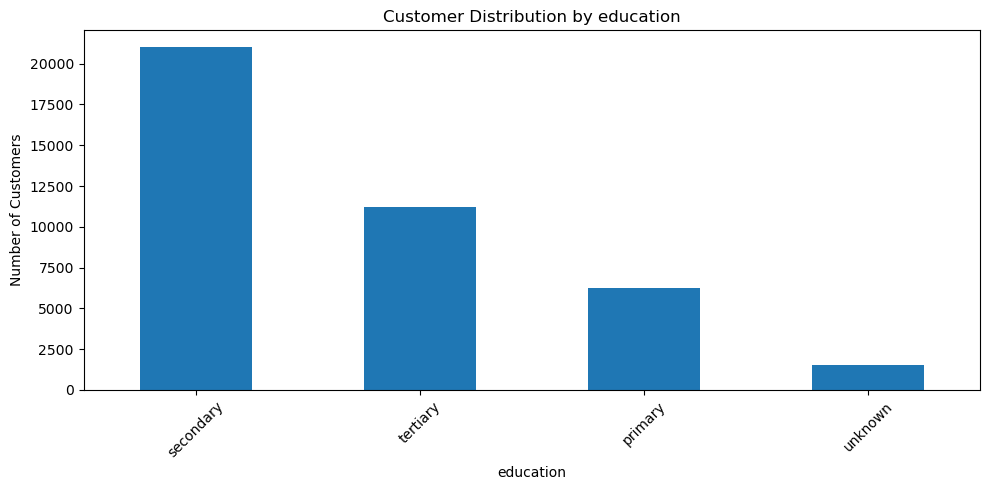

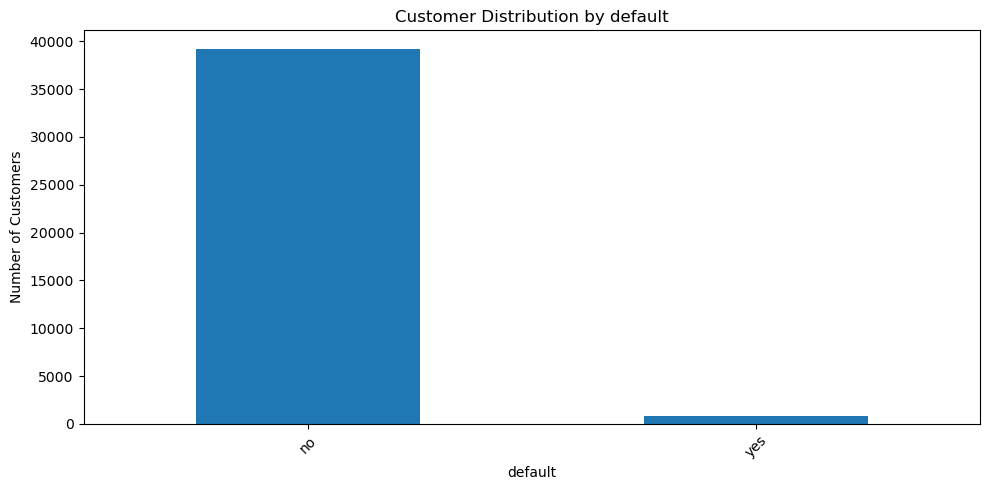

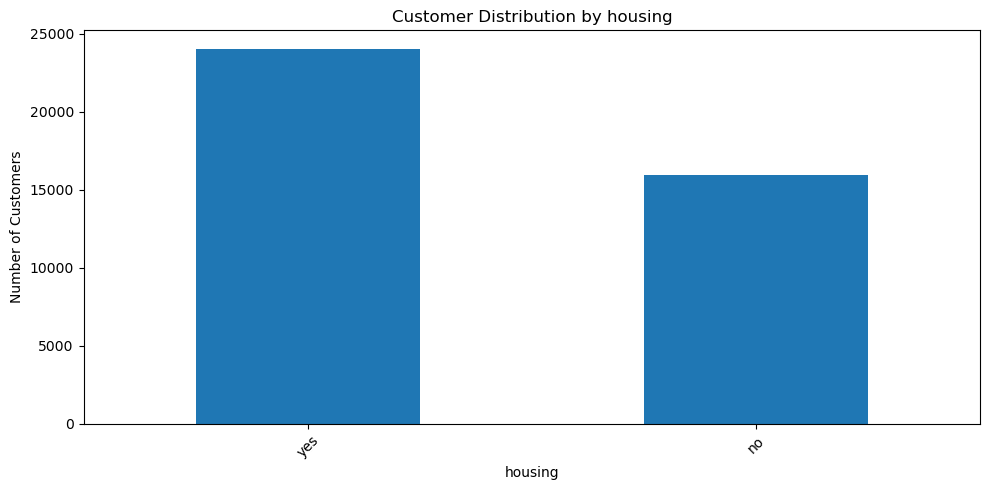

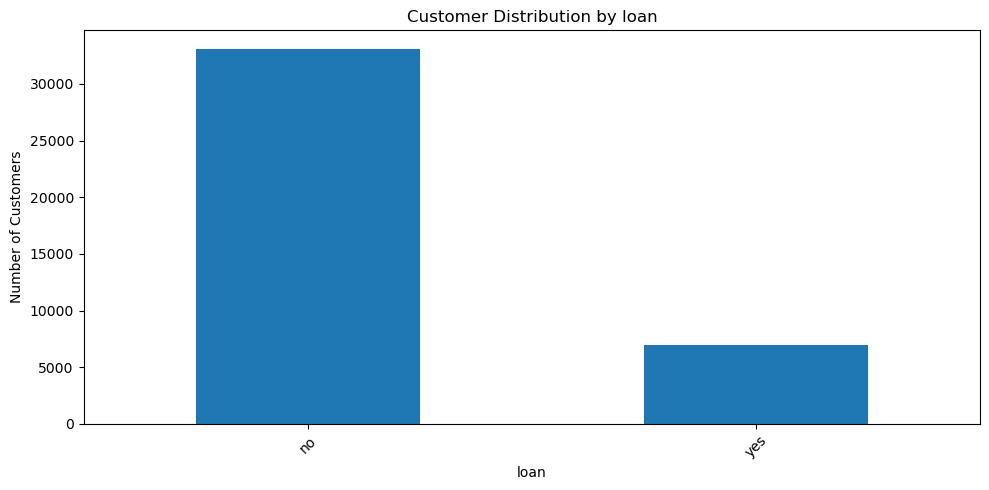

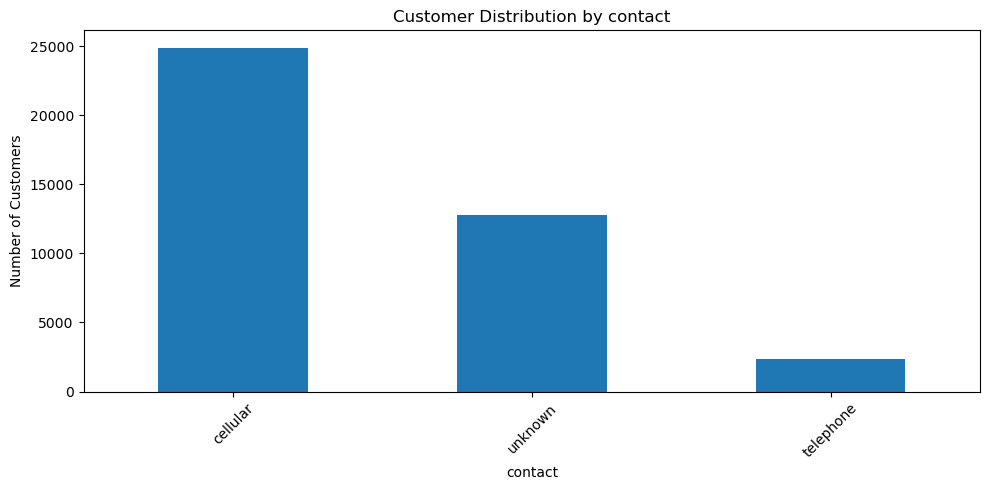

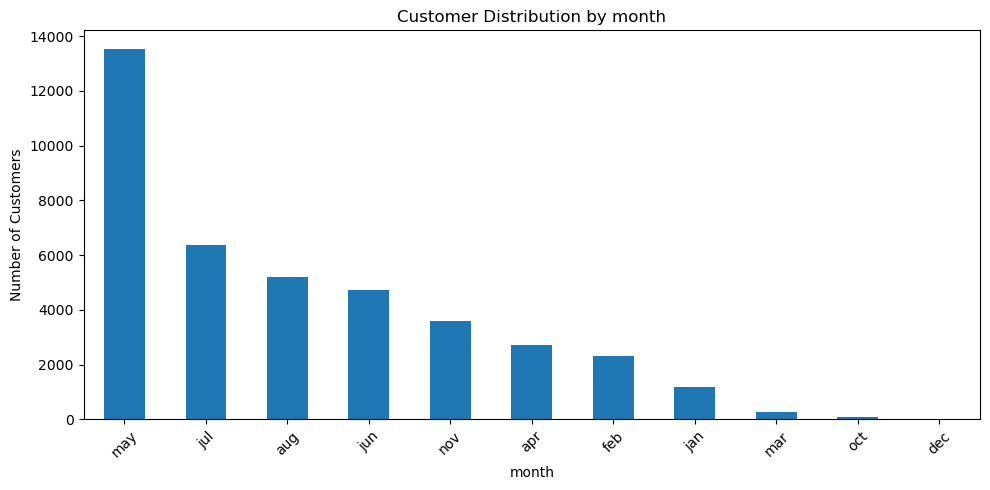

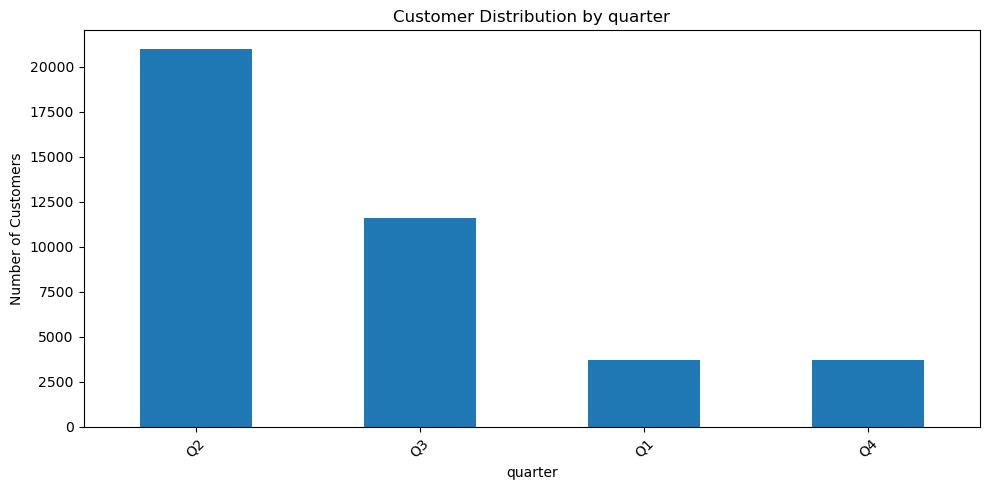

In [37]:
for column in categorical_columns:

    category_counts = df[column].value_counts()

    plt.figure(figsize=(10, 5))

    category_counts.plot(
        kind="bar"
    )

    plt.title(f"Customer Distribution by {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Subscription rate calculation function

In [38]:
def calculate_subscription_rate(data, column):

    analysis = (
        data.groupby(column)["y"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )

    if "yes" in analysis.columns:
        analysis["subscription_rate"] = (
            analysis["yes"] * 100
        ).round(2)

    else:
        analysis["subscription_rate"] = 0

    analysis = analysis.sort_values(
        by="subscription_rate",
        ascending=False
    )

    return analysis

## Subscription rate by job


Subscription Rate by Job:
y                    no       yes  subscription_rate
job                                                 
student        0.843511  0.156489              15.65
retired        0.894920  0.105080              10.51
unemployed     0.913043  0.086957               8.70
management     0.917218  0.082782               8.28
self-employed  0.920792  0.079208               7.92
admin          0.921704  0.078296               7.83
technician     0.927466  0.072534               7.25
unknown        0.927660  0.072340               7.23
entrepreneur   0.937367  0.062633               6.26
services       0.939130  0.060870               6.09
blue-collar    0.942982  0.057018               5.70
housemaid      0.951242  0.048758               4.88


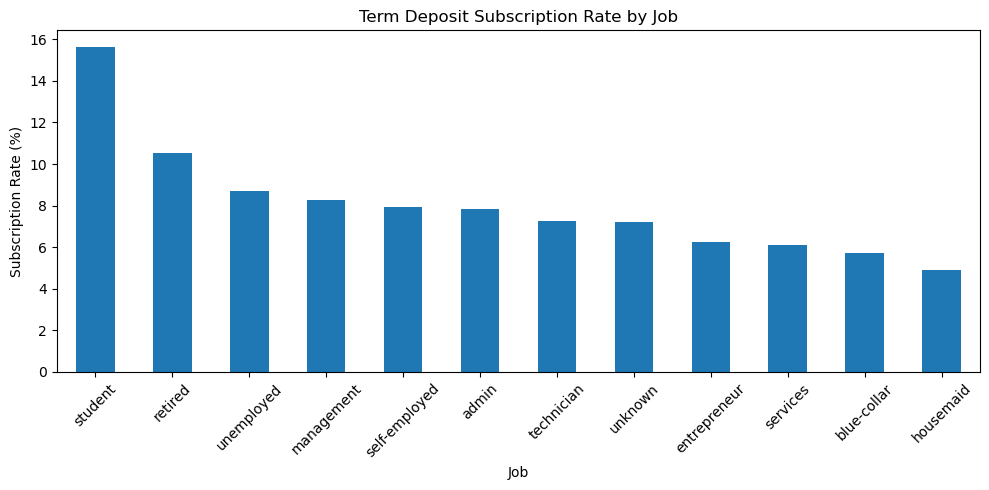

In [39]:
job_analysis = calculate_subscription_rate(
    df,
    "job"
)

print("\nSubscription Rate by Job:")
print(job_analysis)


job_analysis["subscription_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Subscription rate by marital status


Subscription Rate by Marital Status:
y               no       yes  subscription_rate
marital                                        
single    0.905685  0.094315               9.43
divorced  0.917249  0.082751               8.28
married   0.939391  0.060609               6.06


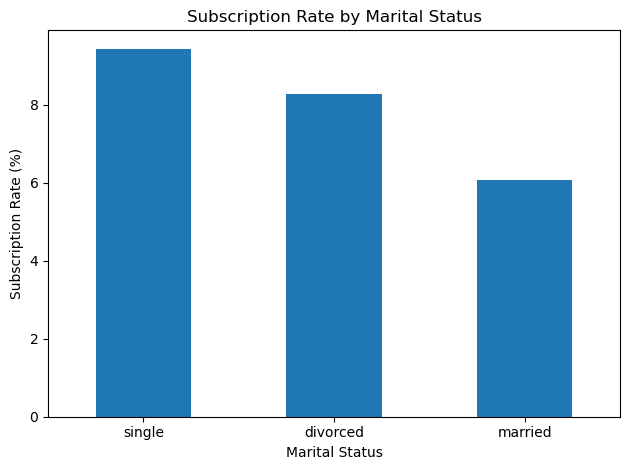

In [40]:

marital_analysis = calculate_subscription_rate(
    df,
    "marital"
)

print("\nSubscription Rate by Marital Status:")
print(marital_analysis)


marital_analysis["subscription_rate"].plot(
    kind="bar"
)

plt.title("Subscription Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Subscription Rate (%)")  # percentage share
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Subscription rate by education


Subscription Rate by Education:
y                no       yes  subscription_rate
education                                       
tertiary   0.908174  0.091826               9.18
secondary  0.932454  0.067546               6.75
unknown    0.937296  0.062704               6.27
primary    0.943700  0.056300               5.63


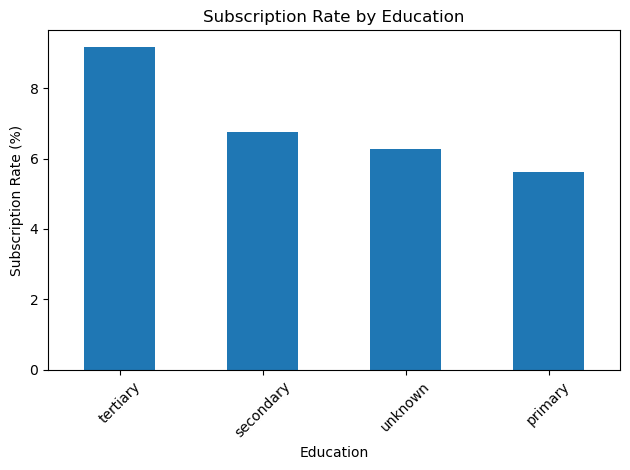

In [41]:

education_analysis = calculate_subscription_rate(
    df,
    "education"
)

print("\nSubscription Rate by Education:")
print(education_analysis)


education_analysis["subscription_rate"].plot(
    kind="bar"
)

plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Subscription rate by default status

In [42]:
default_analysis = calculate_subscription_rate(
    df,
    "default"
)

print("\nSubscription Rate by Credit Default:")
print(default_analysis)


Subscription Rate by Credit Default:
y              no       yes  subscription_rate
default                                       
no       0.927356  0.072644               7.26
yes      0.939431  0.060569               6.06


## Subscription rate by housing loan


Subscription Rate by Housing Loan:
y              no       yes  subscription_rate
housing                                       
no       0.910326  0.089674               8.97
yes      0.939079  0.060921               6.09


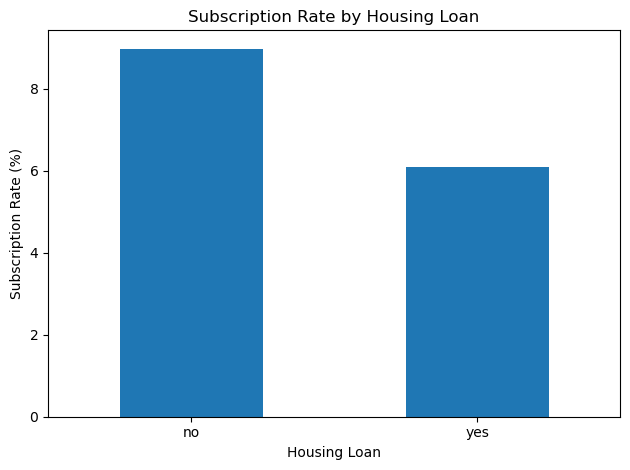

In [43]:
housing_analysis = calculate_subscription_rate(
    df,
    "housing"
)

print("\nSubscription Rate by Housing Loan:")
print(housing_analysis)


housing_analysis["subscription_rate"].plot(
    kind="bar"
)

plt.title("Subscription Rate by Housing Loan")
plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Subscription rate by personal loan


Subscription Rate by Personal Loan:
y           no       yes  subscription_rate
loan                                       
no    0.923919  0.076081               7.61
yes   0.945166  0.054834               5.48


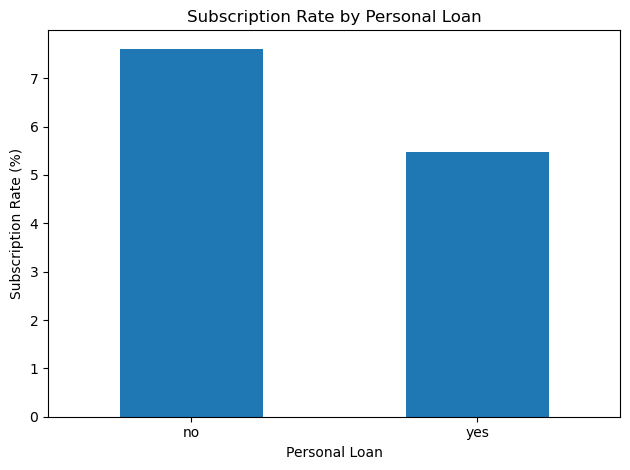

In [44]:

loan_analysis = calculate_subscription_rate(
    df,
    "loan"
)

print("\nSubscription Rate by Personal Loan:")
print(loan_analysis)


loan_analysis["subscription_rate"].plot(
    kind="bar"
)

plt.title("Subscription Rate by Personal Loan")
plt.xlabel("Personal Loan")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Subscription rate by contact type


Subscription Rate by Contact Type:
y                no       yes  subscription_rate
contact                                         
cellular   0.910372  0.089628               8.96
telephone  0.928479  0.071521               7.15
unknown    0.961065  0.038935               3.89


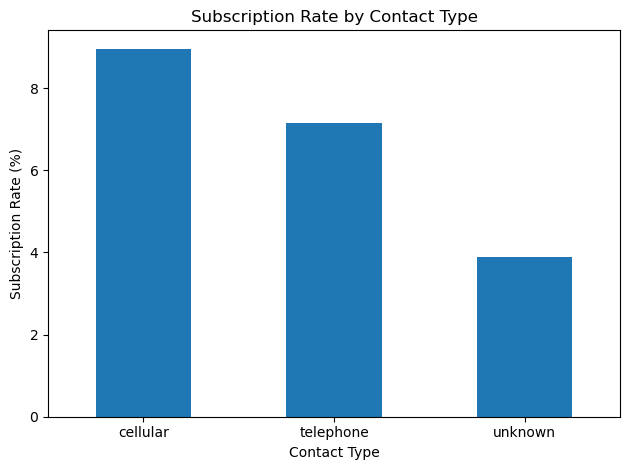

In [45]:
contact_analysis = calculate_subscription_rate(
    df,
    "contact"
)

print("\nSubscription Rate by Contact Type:")
print(contact_analysis)


contact_analysis["subscription_rate"].plot(
    kind="bar"
)

plt.title("Subscription Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## Subscription rate by month


Subscription Rate by Month:
y            no       yes  subscription_rate
month                                       
jan    0.967687  0.032313               3.23
feb    0.888937  0.111063              11.11
mar    0.515504  0.484496              48.45
apr    0.834069  0.165931              16.59
may    0.941546  0.058454               5.85
jun    0.937896  0.062104               6.21
jul    0.939812  0.060188               6.02
aug    0.944775  0.055225               5.52
sep         NaN       NaN                NaN
oct    0.387500  0.612500              61.25
nov    0.938855  0.061145               6.11
dec    0.923077  0.076923               7.69


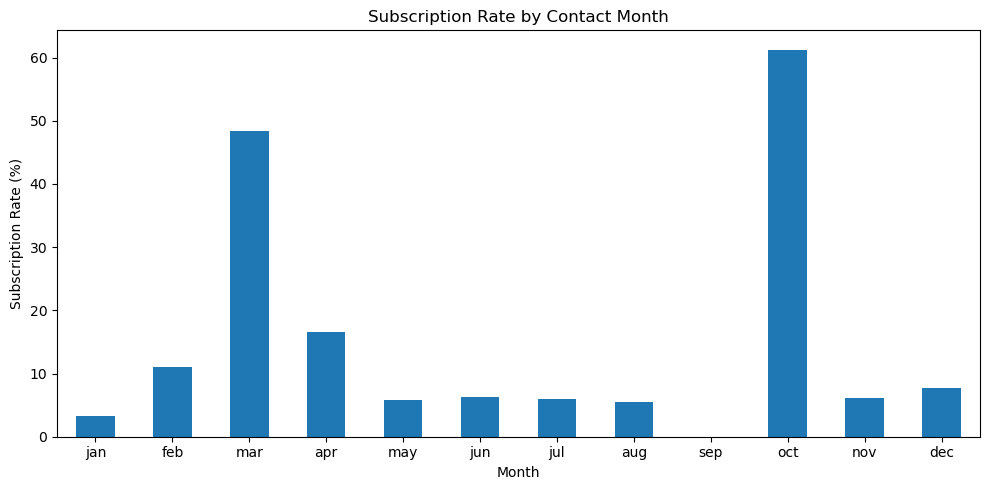

In [46]:
month_order = [
    "jan", "feb", "mar", "apr",
    "may", "jun", "jul", "aug",
    "sep", "oct", "nov", "dec"
]

month_analysis = calculate_subscription_rate(
    df,
    "month"
)

month_analysis = month_analysis.reindex(
    month_order
)

print("\nSubscription Rate by Month:")
print(month_analysis)


month_analysis["subscription_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Subscription Rate by Contact Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Subscription Rate by Quarter:
y              no       yes  subscription_rate
quarter                                       
Q1       0.887936  0.112064              11.21
Q2       0.926801  0.073199               7.32
Q3       0.942044  0.057956               5.80
Q4       0.926849  0.073151               7.32


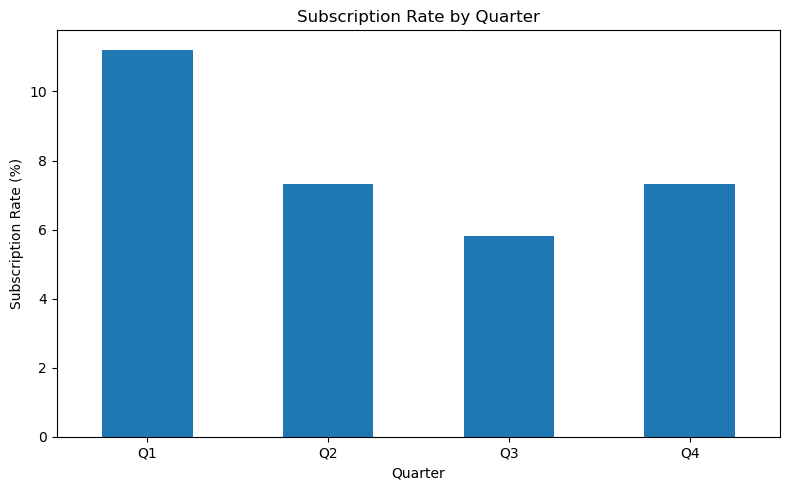

In [47]:
quarter_mapping = {
    "jan": "Q1",
    "feb": "Q1",
    "mar": "Q1",

    "apr": "Q2",
    "may": "Q2",
    "jun": "Q2",

    "jul": "Q3",
    "aug": "Q3",
    "sep": "Q3",

    "oct": "Q4",
    "nov": "Q4",
    "dec": "Q4"
}

# Create new Quarter column

df["quarter"] = df["month"].map(quarter_mapping)

# Calculate subscription rate

quarter_analysis = calculate_subscription_rate(df,"quarter")

# Keep quarters in correct order

quarter_order = ["Q1", "Q2", "Q3", "Q4"]

quarter_analysis = quarter_analysis.reindex(
    quarter_order
)

print("\nSubscription Rate by Quarter:")
print(quarter_analysis)

# Plot graph

quarter_analysis["subscription_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Subscription Rate by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Create age groups

/var/folders/gy/_r3pk94d29g9dz2w48ryr9j40000gn/T/ipykernel_2969/3153184034.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)["y"]



Subscription Rate by Age Group:
y                no       yes  subscription_rate
age_group                                       
Above 60   0.611111  0.388889              38.89
18-30      0.897414  0.102586              10.26
31-40      0.930076  0.069924               6.99
41-50      0.939406  0.060594               6.06
51-60      0.939464  0.060536               6.05


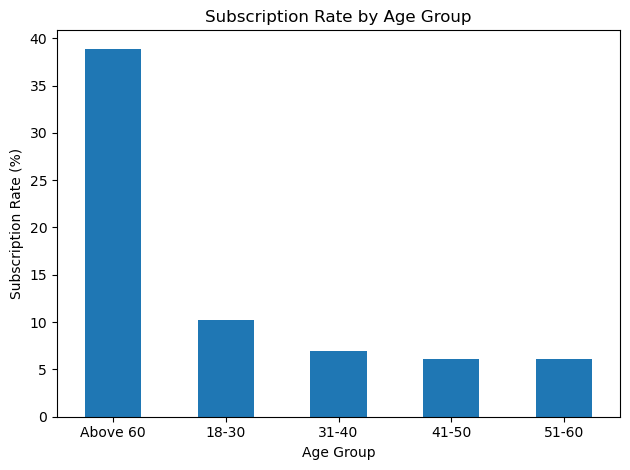

In [48]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=[
        "18-30",
        "31-40",
        "41-50",
        "51-60",
        "Above 60"
    ]
)

age_analysis = calculate_subscription_rate(
    df,
    "age_group"
)

print("\nSubscription Rate by Age Group:")
print(age_analysis)


age_analysis["subscription_rate"].plot(
    kind="bar"
)

plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Create balance groups

/var/folders/gy/_r3pk94d29g9dz2w48ryr9j40000gn/T/ipykernel_2969/3153184034.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)["y"]



Subscription Rate by Balance Group:
y                       no       yes  subscription_rate
balance_group                                          
Above 5000        0.904051  0.095949               9.59
1501-5000         0.905085  0.094915               9.49
501-1500          0.922125  0.077875               7.79
1-500             0.936313  0.063687               6.37
Zero or Negative  0.945821  0.054179               5.42


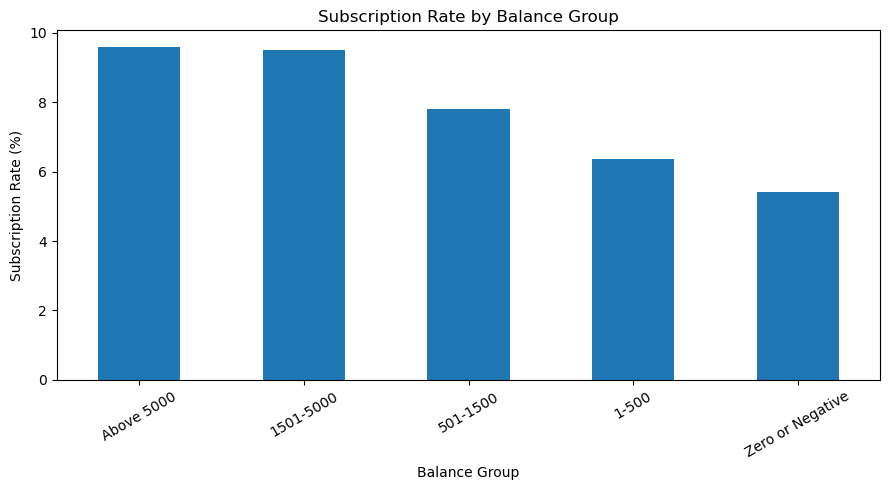

In [49]:
df["balance_group"] = pd.cut(
    df["balance"],
    bins=[
        float("-inf"),
        0,
        500,
        1500,
        5000,
        float("inf")
    ],
    labels=[
        "Zero or Negative",
        "1-500",
        "501-1500",
        "1501-5000",
        "Above 5000"
    ]
)
balance_analysis = calculate_subscription_rate(
    df,
    "balance_group"
)

print("\nSubscription Rate by Balance Group:")
print(balance_analysis)


balance_analysis["subscription_rate"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Subscription Rate by Balance Group")
plt.xlabel("Balance Group")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Create call duration groups

/var/folders/gy/_r3pk94d29g9dz2w48ryr9j40000gn/T/ipykernel_2969/3153184034.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)["y"]



Subscription Rate by Call Duration:
y                       no       yes  subscription_rate
duration_group                                         
Above 10 minutes  0.544048  0.455952              45.60
5-10 minutes      0.892590  0.107410              10.74
3-5 minutes       0.965154  0.034846               3.48
1-3 minutes       0.982706  0.017294               1.73
Below 1 minute    0.999115  0.000885               0.09


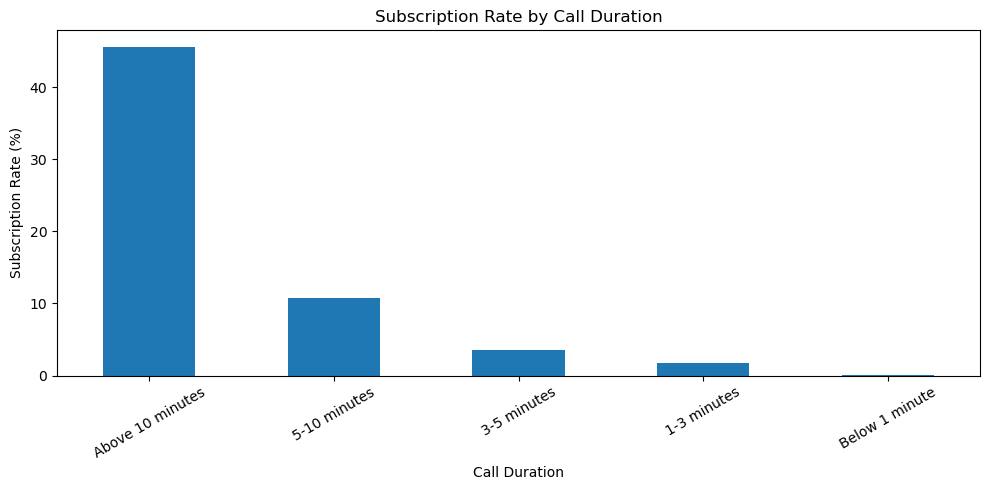

In [50]:
df["duration_group"] = pd.cut(
    df["duration"],
    bins=[
        0,
        60,
        180,
        300,
        600,
        float("inf")
    ],
    labels=[
        "Below 1 minute",
        "1-3 minutes",
        "3-5 minutes",
        "5-10 minutes",
        "Above 10 minutes"
    ],
    include_lowest=True
)

duration_analysis = calculate_subscription_rate(
    df,
    "duration_group"
)

print("\nSubscription Rate by Call Duration:")
print(duration_analysis)


duration_analysis["subscription_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Subscription Rate by Call Duration")
plt.xlabel("Call Duration")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Create campaign contact groups

/var/folders/gy/_r3pk94d29g9dz2w48ryr9j40000gn/T/ipykernel_2969/3153184034.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)["y"]



Subscription Rate by Number of Contacts:
y                        no       yes  subscription_rate
campaign_group                                          
1 Contact          0.914119  0.085881               8.59
3 Contacts         0.929175  0.070825               7.08
2 Contacts         0.931857  0.068143               6.81
4-5 Contacts       0.935817  0.064183               6.42
6-10 Contacts      0.947577  0.052423               5.24
Above 10 Contacts  0.962932  0.037068               3.71


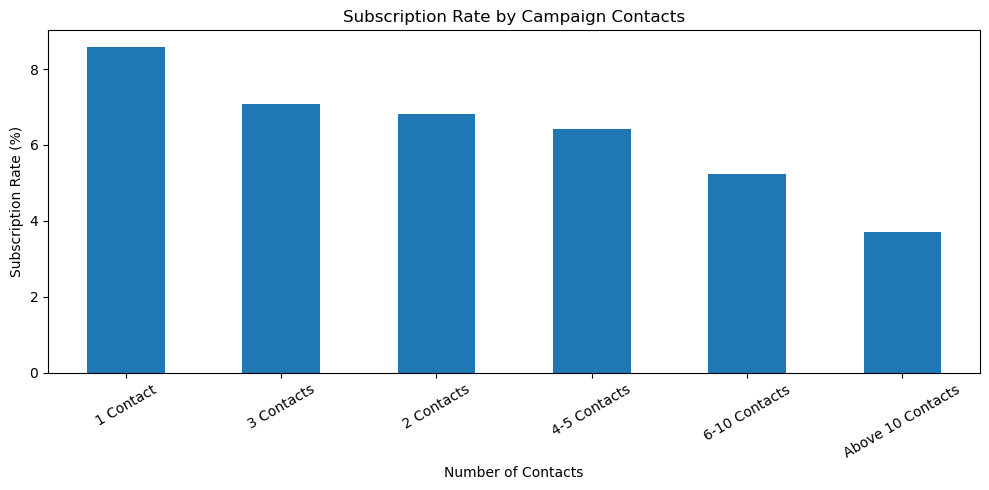

In [51]:
df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=[
        0,
        1,
        2,
        3,
        5,
        10,
        float("inf")
    ],
    labels=[
        "1 Contact",
        "2 Contacts",
        "3 Contacts",
        "4-5 Contacts",
        "6-10 Contacts",
        "Above 10 Contacts"
    ]
)
campaign_analysis = calculate_subscription_rate(
    df,
    "campaign_group"
)

print("\nSubscription Rate by Number of Contacts:")
print(campaign_analysis)


campaign_analysis["subscription_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Subscription Rate by Campaign Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Compare numerical features by target

In [52]:
target_comparison = (
    df.groupby("y")[numerical_columns]
    .mean()
    .round(2)
)

print("\nAverage Numerical Values by Subscription Result:")
print(target_comparison)


Average Numerical Values by Subscription Result:
       age  balance    day  duration  campaign
y                                             
no   40.60  1249.75  16.03    221.41      2.92
yes  39.84  1588.50  15.83    682.96      2.41


## Correlation analysis


Correlation Matrix:
           age  balance   day  duration  campaign  target
age       1.00     0.08 -0.01     -0.04      0.02   -0.02
balance   0.08     1.00  0.01      0.01     -0.01    0.03
day      -0.01     0.01  1.00     -0.03      0.17   -0.01
duration -0.04     0.01 -0.03      1.00     -0.09    0.46
campaign  0.02    -0.01  0.17     -0.09      1.00   -0.04
target   -0.02     0.03 -0.01      0.46     -0.04    1.00


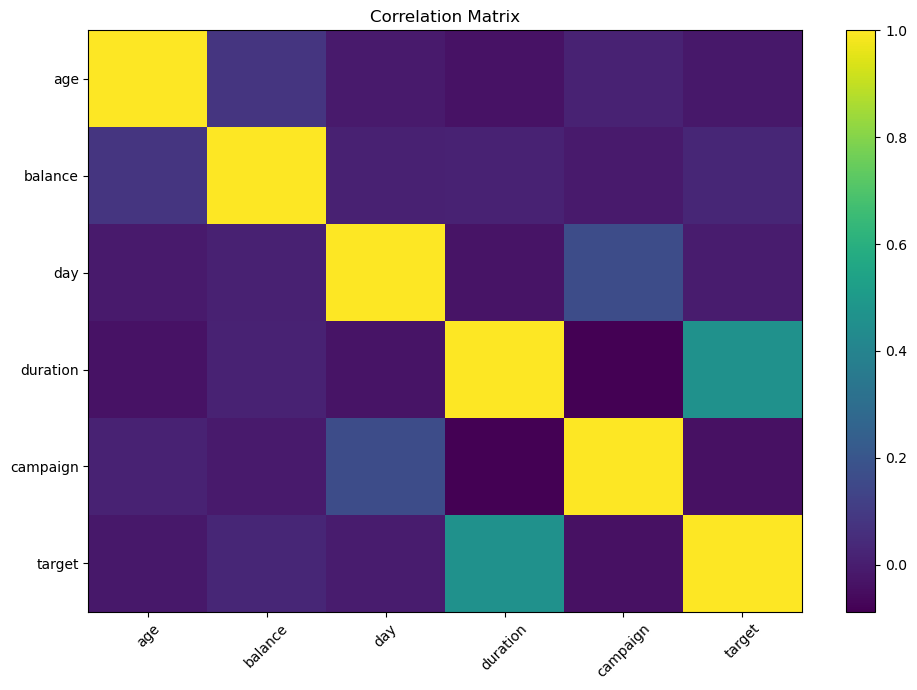

In [53]:
correlation_data = df[numerical_columns].copy()

# Convert target into numbers only for correlation analysis.

correlation_data["target"] = df["y"].map({
    "no": 0,
    "yes": 1
})

correlation_matrix = correlation_data.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(2))


plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## Display top customer segments

In [54]:
print("\nTop Job Segments:")
print(
    job_analysis[["subscription_rate"]].head()
)

print("\nTop Education Segments:")
print(
    education_analysis[["subscription_rate"]].head()
)

print("\nTop Age Segments:")
print(
    age_analysis[["subscription_rate"]].head()
)

print("\nTop Balance Segments:")
print(
    balance_analysis[["subscription_rate"]].head()
)

print("\nBest Contact Months:")
print(
    month_analysis[["subscription_rate"]]
    .sort_values(
        by="subscription_rate",
        ascending=False
    )
    .head()
)


Top Job Segments:
y              subscription_rate
job                             
student                    15.65
retired                    10.51
unemployed                  8.70
management                  8.28
self-employed               7.92

Top Education Segments:
y          subscription_rate
education                   
tertiary                9.18
secondary               6.75
unknown                 6.27
primary                 5.63

Top Age Segments:
y          subscription_rate
age_group                   
Above 60               38.89
18-30                  10.26
31-40                   6.99
41-50                   6.06
51-60                   6.05

Top Balance Segments:
y                 subscription_rate
balance_group                      
Above 5000                     9.59
1501-5000                      9.49
501-1500                       7.79
1-500                          6.37
Zero or Negative               5.42

Best Contact Months:
y      subscription_rate
month  

## Save analysis tables

In [ ]:
job_analysis.to_csv(
    "job_analysis.csv"
)

education_analysis.to_csv(
    "education_analysis.csv"
)

age_analysis.to_csv(
    "age_analysis.csv"
)

balance_analysis.to_csv(
    "balance_analysis.csv"
)

month_analysis.to_csv(
    "month_analysis.csv"
)

duration_analysis.to_csv(
    "duration_analysis.csv"
)

campaign_analysis.to_csv(
    "campaign_analysis.csv"
)

print("\nData analysis completed successfully.")